In [23]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"

# =========================================================
# 1) LOAD ONLY THE 2 JSON FILES
# =========================================================
files_to_compare = ["ensemble.json", "02_ensemble.json", "03_ensemble.json"]

rows = []

for file in files_to_compare:
    path = os.path.join(RESULTS_DIR, file)
    
    with open(path, "r") as f:
        data = json.load(f)
    
    # data = {
    #   "Voting + Bagging": {...},
    #   "Bagging": {...},
    #   ...
    # }
    for category, result in data.items():
        row = {
            "source_file": file,
            "category": result.get("category", category),
            "model_name": result.get("model_name", None),

            "train_accuracy": result["validation_experiment"]["train_metrics"]["accuracy"],
            "val_accuracy": result["validation_experiment"]["validation_metrics"]["accuracy"],
            "train_f1": result["validation_experiment"]["train_metrics"]["f1_macro"],
            "val_f1": result["validation_experiment"]["validation_metrics"]["f1_macro"],

            "train_final_accuracy": result["final_test_experiment"]["train_plus_validation_metrics"]["accuracy"],
            "test_accuracy": result["final_test_experiment"]["test_metrics"]["accuracy"],
            "train_final_f1": result["final_test_experiment"]["train_plus_validation_metrics"]["f1_macro"],
            "test_f1": result["final_test_experiment"]["test_metrics"]["f1_macro"],
        }
        rows.append(row)

df = pd.DataFrame(rows)
display(
    df[["source_file", "category", "model_name"]]
    .sort_values(by="source_file")
)

,source_file,category,model_name
4,02_ensemble.json,Stacking Ensemble,StackingClassifier
5,03_ensemble.json,Voting Ensemble,VotingClassifier
0,ensemble.json,Voting + Bagging,VotingClassifier
1,ensemble.json,Bagging,RandomForestClassifier
2,ensemble.json,Boosting,HistGradientBoostingClassifier
3,ensemble.json,Stacking,StackingClassifier


## Ensemble Models Comparison

### Source file: `../results/ensemble.json`
Contains **4 ensemble models** trained in **`04_ensemble.ipynb`** (by *Leyla*).

- **Stacking**
  - Base models: SVM + KNN + HistGradientBoosting
  - Final estimator: Logistic Regression

- **Boosting**
  - Model: HistGradientBoosting

- **Voting + Bagging**
  - Models: Bagged Decision Tree + KNN + SVM + Logistic Regression
  - Uses weighted soft voting

- **Bagging**
  - Model: Random Forest


---

### Source file: `../results/02_ensemble.json`
Contains **one ensemble model** trained in **`02_knn.ipynb`** (by *Lucas*).

- **Stacking**
  - Base models: Decision Tree + KNN + Logistic Regression
  - Final estimator: HistGradientBoosting


---

### Source file: `../results/03_ensemble.json`
Contains **one ensemble model** trained in **`03_logistic_regression.ipynb`** (by *Sara*).

- **Soft Voting**
  - Models: Logistic Regression + KNN + Decision Tree


---

*Note:*  
For more details about the **hyperparameters and training configuration of each model**, please refer to the corresponding notebook.

In [24]:
print("Comparison Table :")
display(df.sort_values(by="test_accuracy", ascending=False))

Comparison Table :


,source_file,category,model_name,train_accuracy,val_accuracy,train_f1,val_f1,train_final_accuracy,test_accuracy,train_final_f1,test_f1
3,ensemble.json,Stacking,StackingClassifier,0.997000,0.981667,0.997009,0.981625,0.996517,0.9837,0.996520,0.983683
2,ensemble.json,Boosting,HistGradientBoostingClassifier,0.997611,0.979667,0.997609,0.979582,0.997750,0.9806,0.997735,0.980464
0,ensemble.json,Voting + Bagging,VotingClassifier,0.991556,0.979000,0.991555,0.978998,0.991633,0.9798,0.991623,0.979769
4,02_ensemble.json,Stacking Ensemble,StackingClassifier,1.000000,0.977333,1.000000,0.977215,0.999883,0.9796,0.999889,0.979448
5,03_ensemble.json,Voting Ensemble,VotingClassifier,0.992111,0.959000,0.992091,0.958726,0.991533,0.9608,0.991522,0.960421
1,ensemble.json,Bagging,RandomForestClassifier,0.987648,0.955833,0.987716,0.955683,0.986433,0.9596,0.986507,0.959349


## Plot

__Validation vs Test score__:

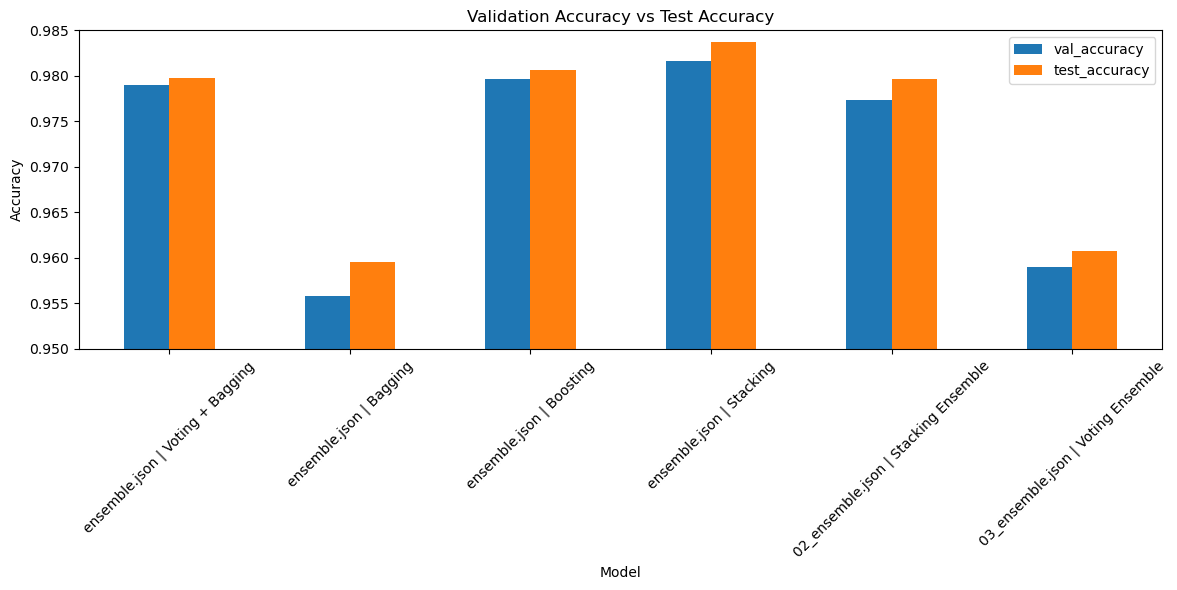

In [25]:
df_plot = df.copy()
df_plot["label"] = df_plot["source_file"] + " | " + df_plot["category"]

ax = df_plot.plot(
    x="label",
    y=["val_accuracy", "test_accuracy"],
    kind="bar",
    figsize=(12, 6),
    rot=45,
    title="Validation Accuracy vs Test Accuracy"
)

plt.ylim(0.95, 0.985)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

__Validation F1 vs Test F1__:

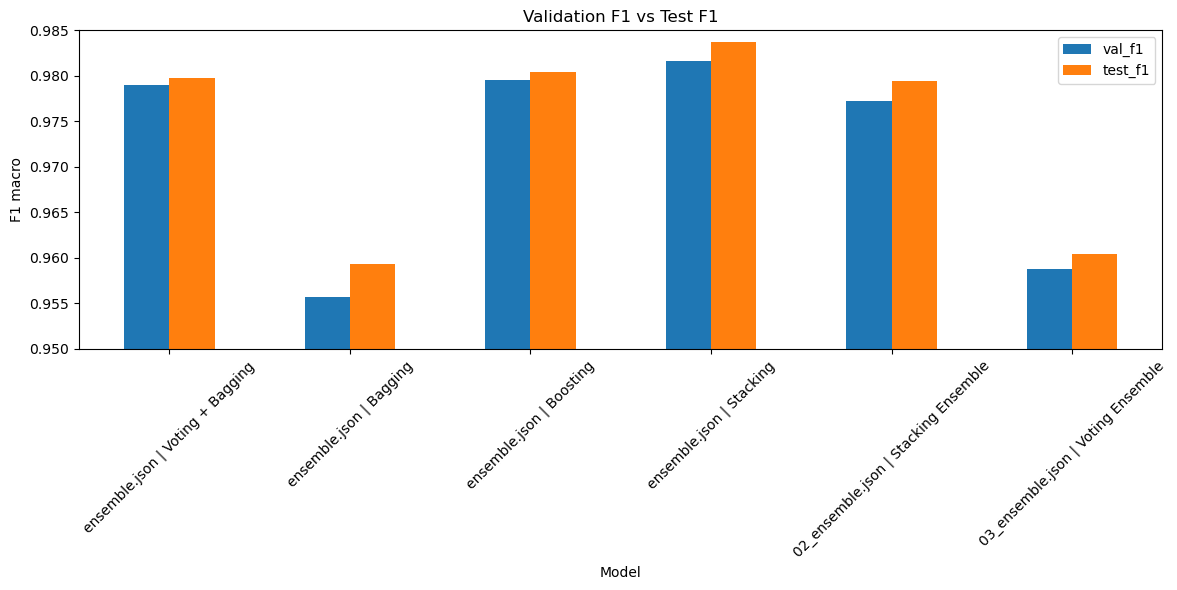

In [26]:
ax = df_plot.plot(
    x="label",
    y=["val_f1", "test_f1"],
    kind="bar",
    figsize=(12, 6),
    rot=45,
    title="Validation F1 vs Test F1"
)
plt.ylim(0.95, 0.985)
plt.ylabel("F1 macro")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

__Test scores__:

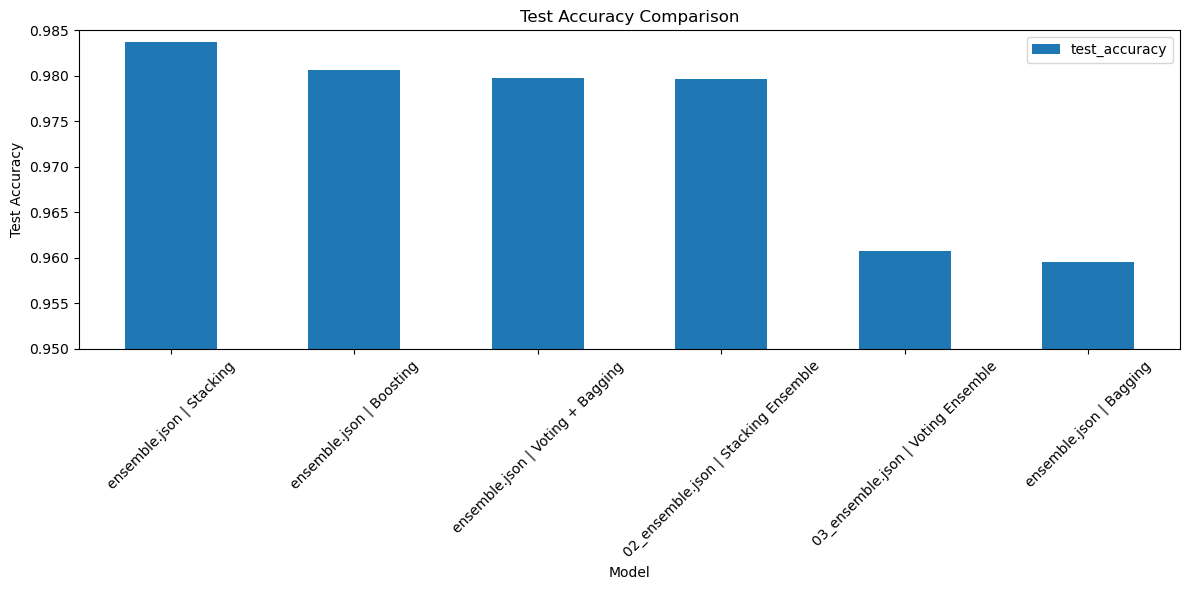

In [27]:
df_test_sorted = df_plot.sort_values(by="test_accuracy", ascending=False)

ax = df_test_sorted.plot(
    x="label",
    y="test_accuracy",
    kind="bar",
    figsize=(12, 6),
    rot=45,
    title="Test Accuracy Comparison"
)
plt.ylim(0.95, 0.985)
plt.ylabel("Test Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

__Summary:__ (from the best to the worst test accuracy)

In [28]:
summary = df[[
    "source_file",
    "category",
    "val_accuracy",
    "test_accuracy",
    "val_f1",
    "test_f1"
]].sort_values(by="test_accuracy", ascending=False)

display(summary)

,source_file,category,val_accuracy,test_accuracy,val_f1,test_f1
3,ensemble.json,Stacking,0.981667,0.9837,0.981625,0.983683
2,ensemble.json,Boosting,0.979667,0.9806,0.979582,0.980464
0,ensemble.json,Voting + Bagging,0.979000,0.9798,0.978998,0.979769
4,02_ensemble.json,Stacking Ensemble,0.977333,0.9796,0.977215,0.979448
5,03_ensemble.json,Voting Ensemble,0.959000,0.9608,0.958726,0.960421
1,ensemble.json,Bagging,0.955833,0.9596,0.955683,0.959349
